In [14]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Como os arquivos estão organizados e como vamos acessá-los de forma reproduzível?

In [9]:
from pathlib import Path

diretorio_raiz = Path.cwd().parent

if ( diretorio_raiz / "UFPR-ALPR dataset" ).is_dir():
    print( "Dataset encontrado!" )

else:
    raise FileNotFoundError(
        f"Dataset não encontrado em {diretorio_raiz}"
    )

diretorio_dataset = diretorio_raiz / "UFPR-ALPR dataset"

for caminho in sorted(diretorio_dataset.iterdir()):
    tipo = "pasta" if caminho.is_dir() else "arquivo"
    print(f"{tipo:7} | {caminho.name}")

Dataset encontrado!
arquivo | README.txt
pasta   | testing
pasta   | training
pasta   | validation


### Quantas imagens e anotações existem em cada conjunto, e há algum arquivo sem seu par?

In [10]:
for conjunto in {"training", "testing", "validation"}:
    pasta = diretorio_dataset / conjunto

    imagens = {
        caminho.relative_to(pasta).with_suffix("")
        for caminho in pasta.rglob("*.png")
    }

    anotacoes = {
        caminho.relative_to(pasta).with_suffix("")
        for caminho in pasta.rglob("*.txt")
    }

    imagens_sem_anotacao = imagens - anotacoes
    anotacoes_sem_imagem = anotacoes - imagens

    print(f"\n{conjunto}")
    print(f"  Imagens: {len(imagens)}")
    print(f"  Anotações: {len(anotacoes)}")
    print(f"  Imagens sem anotação: {len(imagens_sem_anotacao)}")
    print(f"  Anotações sem imagem: {len(anotacoes_sem_imagem)}")


validation
  Imagens: 900
  Anotações: 900
  Imagens sem anotação: 0
  Anotações sem imagem: 0

training
  Imagens: 1800
  Anotações: 1800
  Imagens sem anotação: 0
  Anotações sem imagem: 0

testing
  Imagens: 1800
  Anotações: 1800
  Imagens sem anotação: 0
  Anotações sem imagem: 0


### Verificando conteudo de uma amostra txt

In [11]:
pasta_treino = diretorio_dataset / "training"

arquivos_anotacao = sorted(pasta_treino.rglob("*.txt"))
caminho_anotacao = arquivos_anotacao[0]
caminho_imagem = caminho_anotacao.with_suffix(".png")

conteudo = caminho_anotacao.read_text(encoding="utf-8")

print(f"Anotação: {caminho_anotacao.relative_to(diretorio_dataset)}")
print(f"Imagem:   {caminho_imagem.relative_to(diretorio_dataset)}")
print()
print(conteudo)

Anotação: training\track0001\track0001[01].txt
Imagem:   training\track0001\track0001[01].png

camera: GoPro Hero4 Silver
position_vehicle: 808 311 301 277
	type: car
	make: Suzuki
	model: Grand Vitara
	year: 2013
plate: AXV8804
corners: 912,526 986,531 983,553 912,550
	char 1: 915 534 8 14
	char 2: 923 534 9 14
	char 3: 932 535 9 13
	char 4: 945 536 9 13
	char 5: 954 536 8 13
	char 6: 963 537 8 12
	char 7: 971 537 8 13


### Pegandos cordenadas e transformando para que o pyhton entenda

In [12]:
campos = {}

for linha in conteudo.splitlines():
    if not linha.strip():
        continue

    chave, valor = linha.split(":", maxsplit=1)
    campos[chave.strip()] = valor.strip()

texto_placa = campos["plate"]

cantos_placa = []

for ponto in campos["corners"].split():
    x, y = ponto.split(",")
    cantos_placa.append((int(x), int(y)))

print(f"Texto da placa: {texto_placa}")
print(f"Cantos da placa: {cantos_placa}")

Texto da placa: AXV8804
Cantos da placa: [(912, 526), (986, 531), (983, 553), (912, 550)]


### Testando na imagem para ver se as coordenadas batem

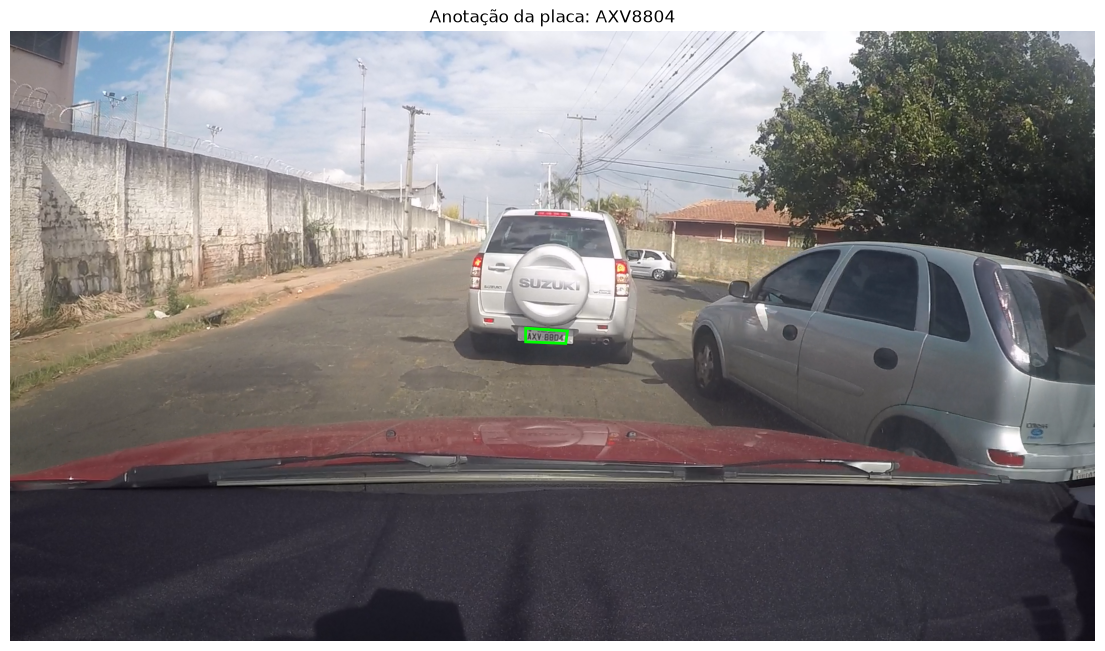

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

imagem = plt.imread(caminho_imagem)

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(imagem)

contorno = Polygon(
    cantos_placa,
    closed=True,
    fill=False,
    edgecolor="lime",
    linewidth=2,
)

ax.add_patch(contorno)
ax.set_title(f"Anotação da placa: {texto_placa}")
ax.set_axis_off()

plt.show()

### Contar tracks e placas distintas em cada divisão e procurar placas compartilhadas entre elas

In [16]:
registros = []

for conjunto in ("training", "validation", "testing"):
    pasta = diretorio_dataset / conjunto

    for caminho_anotacao in sorted(pasta.rglob("*.txt")):
        texto_placa = None

        for linha in caminho_anotacao.read_text(encoding="utf-8").splitlines():
            chave, separador, valor = linha.partition(":")

            if chave.strip() == "plate" and separador:
                texto_placa = valor.strip()
                break

        if not texto_placa:
            raise ValueError(f"Placa ausente ou vazia: {caminho_anotacao}")

        registros.append({
            "conjunto": conjunto,
            "track": caminho_anotacao.parent.relative_to(pasta).as_posix(),
            "placa": texto_placa,
            "caminho_imagem": caminho_anotacao.with_suffix(".png"),
        })

placas_por_conjunto = {}

for conjunto in ("training", "validation", "testing"):
    registros_conjunto = [
        registro
        for registro in registros
        if registro["conjunto"] == conjunto
    ]

    tracks = {registro["track"] for registro in registros_conjunto}
    placas = {registro["placa"] for registro in registros_conjunto}

    placas_por_conjunto[conjunto] = placas

    print(
        f"{conjunto}: "
        f"{len(registros_conjunto)} imagens | "
        f"{len(tracks)} tracks | "
        f"{len(placas)} placas distintas"
    )

print("\nPlacas compartilhadas entre divisões:")

for primeiro, segundo in (
    ("training", "validation"),
    ("training", "testing"),
    ("validation", "testing"),
):
    compartilhadas = (
        placas_por_conjunto[primeiro] & placas_por_conjunto[segundo]
    )

    print(f"{primeiro} × {segundo}: {len(compartilhadas)}")

    if compartilhadas:
        print(f"  {sorted(compartilhadas)}")

training: 1800 imagens | 60 tracks | 60 placas distintas
validation: 900 imagens | 30 tracks | 30 placas distintas
testing: 1800 imagens | 60 tracks | 60 placas distintas

Placas compartilhadas entre divisões:
training × validation: 0
training × testing: 2
  ['AVA1466', 'BBO8514']
validation × testing: 0


In [17]:
from collections import defaultdict

placas_compartilhadas = (
    placas_por_conjunto["training"]
    & placas_por_conjunto["testing"]
)

ocorrencias = defaultdict(int)

for registro in registros:
    if registro["placa"] in placas_compartilhadas:
        chave = (
            registro["placa"],
            registro["conjunto"],
            registro["track"],
        )

        ocorrencias[chave] += 1

for (placa, conjunto, track), quantidade in sorted(ocorrencias.items()):
    print(f"{placa} | {conjunto:10} | {track} | {quantidade} imagens")

AVA1466 | testing    | track0140 | 30 imagens
AVA1466 | training   | track0011 | 30 imagens
BBO8514 | testing    | track0110 | 30 imagens
BBO8514 | training   | track0059 | 30 imagens
